In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from MatrixFactorization import MatrixFactorization as mf
#from CollaborativeFiltering import CollaborativeFiltering as cb

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# movie_ratings = pd.read_csv('./dataset/ratings.csv')
# movie_ratings_small = pd.read_csv('./dataset/ratings_small.csv')
# movies_metadata = pd.read_csv('./dataset/movies_metadata.csv')

movie_ratings = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movie_dataset/ratings.csv')
movie_ratings_small = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movie_dataset/ratings_small.csv')
movies_metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movie_dataset/movies_metadata.csv')

<ipython-input-6-80c1eb9504cb>:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movie_dataset/movies_metadata.csv')


In [7]:
movie_ratings_small.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [8]:
movie_ratings.shape, movie_ratings_small.shape

((26024289, 4), (100004, 4))

In [9]:
movies_metadata = movies_metadata.drop_duplicates(subset='id', keep='first')

In [10]:
movies_metadata = movies_metadata[movies_metadata['id'].str.isdigit()]
movies_metadata['id'] = movies_metadata['id'].astype('int64')

<ipython-input-10-7420a33fdfa0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_metadata['id'] = movies_metadata['id'].astype('int64')


In [11]:
# 두 데이터프레임 병합 (movieId 기준)
movies_total= movies_metadata.merge(movie_ratings,
                                        left_on='id',
                                        right_on='movieId',
                                        how='left')

# 필요 없어진 movieId 열 제거
movies_total = movies_total.drop(columns=['movieId'])


In [12]:
movies_total.shape

(11474436, 27)

In [13]:
movies_total.dropna(subset='userId', inplace=True)

In [14]:
movies_total['userId'] = movies_total['userId'].astype('int64')

In [15]:
a =movies_total[['id','original_title','userId', 'rating']]
a.head()

,id,original_title,userId,rating
0,862,Toy Story,1923,3.0
1,862,Toy Story,2103,5.0
2,862,Toy Story,5380,1.0
3,862,Toy Story,6177,4.0
4,862,Toy Story,6525,4.0


In [16]:
user_rating_counts = a.groupby('id').size()
valid_users = user_rating_counts[user_rating_counts >= 5].index
filtered_users = a[a['userId'].isin(valid_users)].reset_index(drop=True)
train, test = train_test_split(filtered_users, test_size= 0.2, random_state = 42)

In [17]:
user_matrix_train = pd.pivot_table(train, index="userId", columns='original_title',values='rating',aggfunc="mean", fill_value=0)
user_matrix_test = pd.pivot_table(test, index="userId", columns='original_title',values='rating',aggfunc="mean", fill_value=0)

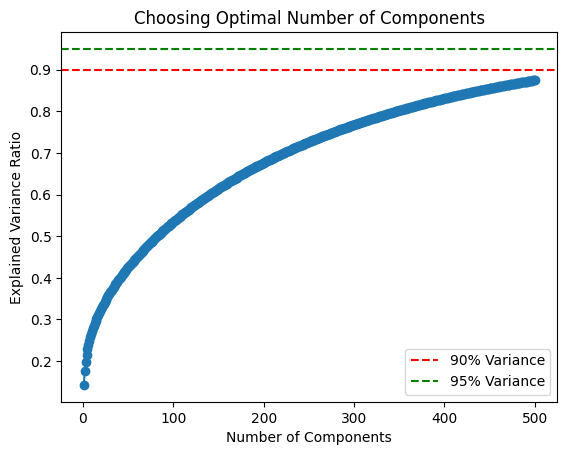

In [ ]:
# 희소 행렬 변환
item_matrix_sparse = csr_matrix(user_matrix_train.T)

# SVD 실행
max_components = min(500, min(item_matrix_sparse.shape) - 1)
svd = TruncatedSVD(n_components=max_components, random_state=42)
X_reduced = svd.fit_transform(item_matrix_sparse)

# 설명된 분산 비율 계산
explained_variance_ratio = np.cumsum(svd.explained_variance_ratio_)

# 그래프 그리기
plt.plot(range(1, max_components+1), explained_variance_ratio, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Choosing Optimal Number of Components')
plt.axhline(y=0.90, color='r', linestyle='--', label="90% Variance")
plt.axhline(y=0.95, color='g', linestyle='--', label="95% Variance")
plt.legend()
plt.show()

In [ ]:
print(explained_variance_ratio[::50])  # 50개 단위로 출력

[0.14277427 0.42798786 0.53650837 0.61575062 0.67765389 0.7276565
 0.76874777 0.80294676 0.83157207 0.85555039]


In [ ]:
explained_variance_ratio[350]

np.float64(0.8029467600426095)

In [ ]:
mf_ = mf(user_matrix_train.T)
k_values = [100, 200, 300, 400, 500]  # 실험할 k 값 리스트
for k in k_values:
    actual_items, predicted_items = mf_.predict(k, top_k=20)
    precision = mf_.precision_at_k(actual_items, predicted_items, 20)
    recall = mf_.recall_at_k(actual_items, predicted_items, 20)
    print(f"k={k}, Precision: {precision:.4f}, Recall: {recall:.4f}")

k=100, Precision: 0.3498, Recall: 0.6167
k=200, Precision: 0.4148, Recall: 0.6974
k=300, Precision: 0.4419, Recall: 0.7328
k=400, Precision: 0.4557, Recall: 0.7535
k=500, Precision: 0.4634, Recall: 0.7674


In [ ]:
k_values = [100,200, 300, 400, 500]  # 실험할 k 값 리스트
for k in k_values:
    actual_items, predicted_items = mf_.predict(k, top_k=10)
    precision = mf_.precision_at_k(actual_items, predicted_items, 10)
    recall = mf_.recall_at_k(actual_items, predicted_items, 10)
    print(f"k={k}, Precision: {precision:.4f}, Recall: {recall:.4f}")

k=100, Precision: 0.4614, Recall: 0.5523
k=200, Precision: 0.5406, Recall: 0.6328
k=300, Precision: 0.5656, Recall: 0.6615
k=400, Precision: 0.5766, Recall: 0.6779
k=500, Precision: 0.5824, Recall: 0.6868


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

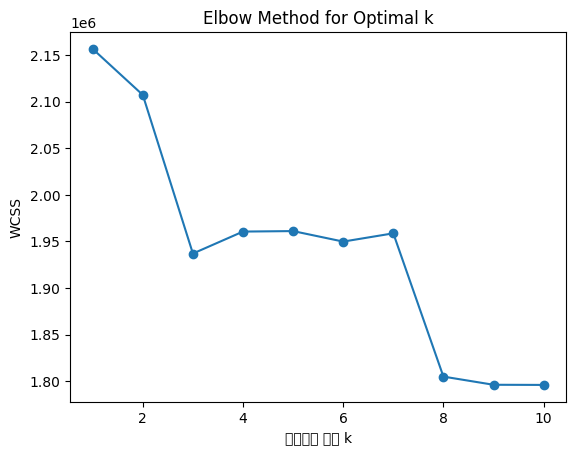

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
max_component = 350
# 희소 행렬로 변환 (User-Item Matrix가 이미 희소 행렬이면 생략 가능)
item_matrix_sparse = csr_matrix(user_matrix_train.T)
max_components = min(max_component, min(item_matrix_sparse.shape) - 1)

svd = TruncatedSVD(n_components=max_components, random_state=42)
X_reduced = svd.fit_transform(item_matrix_sparse)
batch_size = min(1024, X_reduced.shape[0])  # 배치 크기 최적화
wcss = []
for k in range(1, 11):  # k를 1부터 10까지 테스트
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=batch_size, n_init="auto")
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS 값

# 그래프 그리기
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('클러스터 개수 k')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

In [32]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import MiniBatchKMeans
from MatrixFactorization import MatrixFactorization
import scipy

class CollaborativeFiltering:
  def __init__(self, user_movie_matrix, n_clusters, k, k_neighbors = 10):
      self.user_movie_matrix = user_movie_matrix
      self.optimal_k = k
      self.n_clusters = n_clusters
      self.k_neighbors = k_neighbors
      self.dense_matrix = None
      self.k_means = None
      self.user_labels = None
      self.user_similarity = None
      self.item_similarity = None
      self.user_means = None
      self.nearest_users = None

  def clustering(self):
      """차원축소후 KMeans로 사용자 군집화"""
      user_matrix_sparse = csr_matrix(self.user_movie_matrix)
      svd = TruncatedSVD(n_components=self.optimal_k, random_state=42)
      X_reduced = svd.fit_transform(user_matrix_sparse)
      batch_size = min(1024, X_reduced.shape[0])  # 배치 크기 최적화
      self.k_means = MiniBatchKMeans(n_clusters=self.n_clusters, random_state=42, batch_size=batch_size, n_init="auto")
      user_clusters = self.k_means.fit_predict(X_reduced)
      self.user_labels = user_clusters

  def get_nearest_neighbors(self, user_index):
      """동일 클러스터 내에서 NearestNeighbors를 사용해 가장 가까운 유저 찾기"""
      user_cluster = self.user_labels[user_index]  # 현재 사용자가 속한 클러스터 찾기
      cluster_indices = [i for i, label in enumerate(self.user_labels) if label == user_cluster]

      # 클러스터 내 최근접 이웃 찾기
      knn = NearestNeighbors(n_neighbors=self.k_neighbors, metric='cosine')
      knn.fit(self.user_movie_matrix.iloc[cluster_indices].values)

      user_vector = self.user_movie_matrix.iloc[user_index].values.reshape(1, -1)
      distances, indices = knn.kneighbors(user_vector)
      nearest_users = [cluster_indices[i] for i in indices[0]]  # 원래 인덱스로 변환
      return nearest_users

  def calculate_pearson_similarity(self, user_id):

      if self.dense_matrix is None:
        mf = MatrixFactorization(self.user_movie_matrix)
        reduced_matrix = mf.fit(self.optimal_k)
        self.dense_matrix = csr_matrix(reduced_matrix)
      reduced_matrix_csr = self.dense_matrix

      user_index = self.user_movie_matrix.index.get_loc(user_id)
      target_user_vector = reduced_matrix_csr[user_index].toarray().flatten()
      nearest_users = self.get_nearest_neighbors(user_index)
      similarities = {}

      for other_user_id in nearest_users:
        if other_user_id != user_index:
            other_user_vector = reduced_matrix_csr[other_user_id].toarray().flatten()
            # 공통으로 평가한 아이템만 선택 (0 제외)
            common_indices = (target_user_vector != 0) & (other_user_vector != 0)
            if np.sum(common_indices) > 1:  # 공통 아이템이 2개 이상일 때만 계산
                target_values = target_user_vector[common_indices]
                other_values = other_user_vector[common_indices]
                corr, _ = pearsonr(target_values, other_values)
                similarities[other_user_id] = corr
            else:
                similarities[other_user_id] = 0  # 공통 평가 데이터가 없으면 0 처리
      self.user_similarity = similarities
      return similarities

  def adjusted_cosine_similarity(self, item_index):
      """
      아이템 간의 Adjusted Cosine Similarity를 계산하여 item_similarity 행렬을 저장
        """
      if self.dense_matrix is None:
        mf = MatrixFactorization(self.user_movie_matrix)
        reduced_matrix = mf.fit(self.optimal_k)
        self.dense_matrix = csr_matrix(reduced_matrix)
      user_means = np.array([np.nanmean(row[row > 0]) if np.any(row > 0) else 0 for row in self.dense_matrix.toarray()])

      # ✅ 조정된 행렬 생성

      nearest_users = self.get_nearest_neighbors(item_index)
      self.nearest_users = nearest_users
      if len(nearest_users) == 0:
            print(f"경고: 아이템 {item_index}을 평가한 유저가 없습니다. 기본값 반환")
            return np.zeros(self.dense_matrix.shape[0])
      adjusted_matrix = self.dense_matrix[nearest_users,:].copy()
      user_means = np.array([np.nanmean(row[row > 0]) if np.any(row > 0) else 0 for row in self.dense_matrix.toarray()])

    # ✅ 조정된 행렬 생성
      adjusted_matrix.data = adjusted_matrix.data - user_means[adjusted_matrix.indices]

      # ✅ Adjusted Cosine Similarity 계산
      item_similarity = cosine_similarity(adjusted_matrix, dense_output=False)

      # 조정된 코사인 유사도 계산
      self.item_similarity = item_similarity
      return self.item_similarity

  def user_based_predict(self, user_id, item_name, similarities):
    """
    특정 사용자와 아이템에 대해 평점을 예측.

    Parameters:
        user_id (int): 예측할 사용자 ID
        item_name (int): 예측할 아이템
        similarities (dict): 사용자 간 유사도 딕셔너리
        k (int): 유사한 사용자 수
    Returns:
        float: 예측 평점
    """
    item_id = self.user_movie_matrix.columns.get_loc(item_name)
    user_mean = self.user_movie_matrix.loc[user_id]
    self.user_mean = user_mean[user_mean != 0].mean() if not user_mean[user_mean != 0].empty else 0
    rated_users = [user for (user, value) in similarities.items() if self.user_movie_matrix.iloc[user, item_id] != 0
                  and value > 0]
    if len(rated_users) == 0:
      return self.user_mean
    # 유사도 기준으로 해당 아이템에 대해 평가한 사용자 유사도가 0이상인 사용자만을 선택
    top_k_users = sorted([(int(self.user_movie_matrix.index[user]), similarities[user]) for user in rated_users if similarities[user] > 0], key=lambda x: x[1], reverse=True)

    # 사용자 평균 평점 계산
    numerator = 0
    denominator = 0
    for similar_user, sim in top_k_users:
        rating = self.user_movie_matrix.loc[similar_user, item_name]
        if rating !=0:
            # 유사 사용자의 평균 평점
            similar_user_mean = self.user_movie_matrix.loc[similar_user]
            similar_user_mean = similar_user_mean[similar_user_mean != 0].mean() if not similar_user_mean[similar_user_mean != 0].empty else 0
            # 유사 사용자의 평점과 평균 차이
            rating_diff = self.user_movie_matrix.loc[similar_user, item_name] - similar_user_mean
            numerator += sim * rating_diff
            denominator += abs(sim)
    if denominator == 0:
        return self.user_mean  # 유사한 사용자가 없을 경우 평균 평점 반환
    return self.user_mean + (numerator / denominator)

  def item_based_predict(self,item_index, user_id, k =10):
    """
      특정 사용자와 아이템에 대해 평점을 예측

      Parameters:
        item_index (str): 아이템 인덱스
        user_id (int): 사용자 ID
        top_n (int): 유사한 아이템 수

      Returns:
        float: 예측 평점
      """
    sim_vector = self.item_similarity[0].toarray()[0][1:]

    # # 유사도가 높은 순서대로 후보 아이템 인덱스 정렬
    candidate_indices = np.argsort(sim_vector)[::-1]
    recommendations = []
    cluster_matrix = self.user_movie_matrix
    for idx in candidate_indices:
        # ratings_matrix에서 해당 아이템(idx)의 평점 데이터가 있는지 확인 (nnz > 0이면 평점 존재)
      item_idx = self.nearest_users[idx]
      if self.dense_matrix.getrow(item_idx).nnz > 0 and cluster_matrix.iloc[item_idx].loc[user_id]:
        recommendations.append((idx, cluster_matrix.iloc[item_idx].loc[user_id], sim_vector[idx]))
        # 충분한 추천 아이템을 찾으면 종료
      if len(recommendations) >= k:
        break
    user_index = cluster_matrix.columns.get_loc(user_id)
    user_ratings = cluster_matrix.iloc[:,user_index]
    user_mean = user_ratings[user_ratings != 0].mean()
    numerator = 0
    denominator = 0
    for item, rating, sim in recommendations:
          numerator += sim * rating
          denominator += abs(sim)
    if denominator == 0:
        return user_mean  # 유사한 사용자가 없을 경우 평균 평점 반환
    return numerator / denominator if denominator != 0 else 0

In [33]:
k = 3
item_title = "장화, 홍련"
item_idx = user_matrix_train.T.index.get_loc(item_title)
cb_ = CollaborativeFiltering(user_matrix_train.T, n_clusters=3, k=350)
cb_.clustering()
similarities = cb_.adjusted_cosine_similarity(item_idx)



In [34]:
user_id = 2
ratings = cb_.item_based_predict(item_idx, user_id)
print(f"사용자 {user_id}가 '{item_title}'에 부여할 예측 평점: {ratings}")

사용자 2가 '장화, 홍련'에 부여할 예측 평점: 3.142857142857143


In [35]:
similarities.toarray()[0], cb_.nearest_users

(array([1.        , 0.92589802, 0.89793775, 0.91108961, 0.90824072,
        0.87314831, 0.90047722, 0.89333267, 0.89718477, 0.90742644]),
 [4123, 255, 776, 3055, 2274, 3469, 1865, 3261, 621, 2552])

In [36]:
nearest_users = cb_.get_nearest_neighbors(item_idx)
for user in nearest_users:
  print(user_matrix_train.T.index[user])

장화, 홍련
Arctic Tale
Das Millionenspiel
The Darjeeling Limited
Once
The Sugarland Express
Life Stinks
The Last Time
Chasing Mavericks
Robin Hood: Prince of Thieves


In [151]:
actual_item = user_matrix_test.loc[user_id]
actual_items = actual_item[actual_item > 0].sort_values(ascending=False)[:10]
actual_items.index.values

array(['Night on Earth', 'The 39 Steps', 'Parenthood'], dtype=object)

In [157]:
user_matrix_train.loc[user_id,actual_items.index.values]

,2
original_title,
Night on Earth,0.0
The 39 Steps,0.0
Parenthood,0.0


In [154]:

# 사용자 ID=2에게 추천, 테스트데이터에서 확인할수있는 실제 아이템이 없기 때문에 추천이 어려움
user_id = 2
from collections import defaultdict
user2 = user_matrix_train.loc[user_id]
recomended_items = user2[user2 >=4].index.values
recomended_items
item_scores = defaultdict(float)

for item_title in recomended_items:
  item_idx = user_matrix_train.T.index.get_loc(item_title)
  similarities = cb_.adjusted_cosine_similarity(item_idx)
  sim = similarities.toarray()[0]
  for idx in range(1, len(cb_.nearest_users)):
      score = sim[idx]
      item_idx = cb_.nearest_users[idx]
      item_scores[item_idx] += score

In [155]:
recomended_items

array(['A Nightmare on Elm Street', 'Hable con ella',
       'Interview with the Vampire', 'La belle et la bête',
       'The Matrix Revolutions', '英雄'], dtype=object)

In [156]:
sorted_items = sorted(item_scores.items(), key=lambda x: x[1], reverse=True)
sorted_items
K = 10
kitems = [item for item, score in sorted_items[:K]]
for item in kitems:
  print(user_matrix_train.T.index[item])

Un chien andalou
Dark Star
Afterwards
The Birth of a Nation
Fantômas
The Wild Bunch
Murder at the Gallop
Elsker dig for evigt
Monsoon Wedding
WarGames


In [111]:
# Night on Earth	5.0
# The 39 Steps	4.0
# Parenthood

'Un chien andalou'

In [ ]:
def predict(train_data, test_data):
    predicted_matrix = test_data.copy()
    cb_ = CollaborativeFiltering(train_data, n_clusters=3, k=350)
    cb_.clustering()
    count = 0
    for item_name in test_data.index:
        if item_name not in train_data.index.values:
            continue  # train_data에 없는 유저는 스킵
        for user_id in test_data.columns:
            if user_id not in train_data.columns:
                continue  # train_data에 없는 영화는 스킵
            if test_data.loc[item_name, user_id] > 0:
                item_idx = train_data.index.get_loc(item_name)
                cb_.adjusted_cosine_similarity(item_idx)
                score = cb_.item_based_predict(item_idx, user_id)
                predicted_matrix.loc[item_name, user_id] = score
                count += 1
    return predicted_matrix, count

In [ ]:
train_data = user_matrix_train.T
test_data = user_matrix_test.T

predicted, count = predict(train_data, test_data)

KeyboardInterrupt: 

In [ ]:
predicted

userId,2,3,5,11,12,14,15,16,17,19,...,172803,172897,173299,173467,173845,173847,173873,174371,174615,174645
original_title,,,,,,,,,,,,,,,,,,,,,
!Women Art Revolution,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'R Xmas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...Più forte ragazzi!,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10 Items or Less,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10 Things I Hate About You,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
파란대문,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
해안선,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
헬로우 고스트,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
